In [2]:
#importing the Libraies
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
# Reading the Dataset
dataset = pd.read_csv('50_Startups.csv')

In [4]:
dataset

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94
5,131876.90,99814.71,362861.36,New York,156991.12
6,134615.46,147198.87,127716.82,California,156122.51
7,130298.13,145530.06,323876.68,Florida,155752.60
8,120542.52,148718.95,311613.29,New York,152211.77
9,123334.88,108679.17,304981.62,California,149759.96


In [5]:
datasets=pd.get_dummies(dataset,drop_first=True)

In [6]:
datasets

,R&D Spend,Administration,Marketing Spend,Profit,State_Florida,State_New York
0,165349.20,136897.80,471784.10,192261.83,False,True
1,162597.70,151377.59,443898.53,191792.06,False,False
2,153441.51,101145.55,407934.54,191050.39,True,False
3,144372.41,118671.85,383199.62,182901.99,False,True
4,142107.34,91391.77,366168.42,166187.94,True,False
5,131876.90,99814.71,362861.36,156991.12,False,True
6,134615.46,147198.87,127716.82,156122.51,False,False
7,130298.13,145530.06,323876.68,155752.60,True,False
8,120542.52,148718.95,311613.29,152211.77,False,True
9,123334.88,108679.17,304981.62,149759.96,False,False


In [8]:
indep=datasets[['R&D Spend','Administration', 'Marketing Spend','State_Florida', 'State_New York']]
dep=datasets[['Profit']]

In [9]:
#split into training set and test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(indep, dep, test_size = 1/3, random_state = 0)

In [10]:
from sklearn.tree import DecisionTreeRegressor
regressor=DecisionTreeRegressor(criterion = 'absolute_error', max_features = 'log2' , splitter = 'random')
regressor=regressor.fit(X_train,y_train)

In [11]:
y_pred=regressor.predict(X_test)

In [12]:
from sklearn.metrics import r2_score
r_score=r2_score(y_test,y_pred)

In [13]:
r_score

0.8068388937031743

In [14]:
regressor.feature_importances_

array([0.73372516, 0.02121444, 0.21520469, 0.01580291, 0.01405279])

In [15]:
regressor.max_features_

2

In [16]:
regressor.tree_

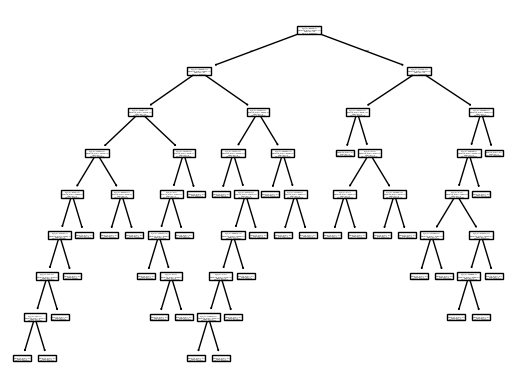

In [17]:
from sklearn import tree
tree.plot_tree(regressor)
plt.show()

In [18]:
rd_input=float(input("R&D:"))
admin_input=float(input("Admin"))
mark_input=float(input("Marketing "))
fol_input=int(input("State_flo 0 or 1:"))
new_input=int(input("State_new 0 or 1:"))

R&D: 20000
Admin 30000
Marketing  45000
State_flo 0 or 1: 0
State_new 0 or 1: 1


In [19]:
result=regressor.predict([[rd_input,admin_input,mark_input,fol_input,new_input]])

C:\Anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


In [20]:
result

array([65200.33])